# Read file

In [39]:
import pandas as pd
data=pd.read_csv("insurance.csv")
display(data.head())

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


# Shape of data

In [40]:
print("we have rows:{}".format(data.shape[0]),
      "\n we have colunms:{}".format(data.shape[1]))


we have rows:1338 
 we have colunms:7


# Null values

In [41]:
import numpy as np
display(data.isnull().sum())
np.sum(pd.isnull(data))


,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:84: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


# unique values in specific coulnms

In [42]:
display(data["smoker"].unique())
display(data["age"].unique())
display(data["sex"].unique())

array(['yes', 'no'], dtype=object)

array([19, 18, 28, 33, 32, 31, 46, 37, 60, 25, 62, 23, 56, 27, 52, 30, 34,
       59, 63, 55, 22, 26, 35, 24, 41, 38, 36, 21, 48, 40, 58, 53, 43, 64,
       20, 61, 44, 57, 29, 45, 54, 49, 47, 51, 42, 50, 39])

array(['female', 'male'], dtype=object)

# fill nulll values

In [43]:
num=data['smoker'].mode()[0]
data['smoker']=data["smoker"].fillna(num)
display(data["smoker"])

,smoker
0,yes
1,no
2,no
3,no
4,no
...,...
1333,no
1334,no
1335,no
1336,no


# covert to int

In [56]:
display(data.info())
data['bmi'] = data.bmi.astype(np.int64)
display(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(2)
memory usage: 62.8+ KB


None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   int64  
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   charges   1338 non-null   float64
dtypes: float64(1), int64(3), object(2)
memory usage: 62.8+ KB


None

drop **colunms**

In [52]:
data.drop("region" ,axis=1,inplace=True)
display(data.head())

,age,sex,bmi,children,smoker,charges
0,19,female,27.900,0,yes,16884.92400
1,18,male,33.770,1,no,1725.55230
2,28,male,33.000,3,no,4449.46200
3,33,male,22.705,0,no,21984.47061
4,32,male,28.880,0,no,3866.85520


data types of colunms

In [57]:
display(data.dtypes)

,0
age,int64
sex,object
bmi,int64
children,int64
smoker,object
charges,float64


# spliting to x and y

In [60]:
x=data.iloc[:,0:-1]
x.shape
y=data.iloc[:,-1]
y.shape
display(data.shape)

(1338, 6)

In [77]:
# Convert continuous 'charges' into categorical bins for classification
data['charges_category'] = pd.qcut(data['charges'], q=3, labels=['low', 'medium', 'high'])
y = data['charges_category']

print("Original 'charges' column head:")
display(data['charges'].head())
print("\nNew 'charges_category' column head and value counts:")
display(y.head())
display(y.value_counts())

Original 'charges' column head:


,charges
0,16884.92400
1,1725.55230
2,4449.46200
3,21984.47061
4,3866.85520



New 'charges_category' column head and value counts:


,charges_category
0,high
1,low
2,low
3,high
4,low


,count
charges_category,
low,446
medium,446
high,446


Now that the target variable `y` is categorical, we can apply classification models and evaluate them using accuracy, precision, recall, and F1-score.

# convert obj to int columns

In [64]:
c_columns=x.select_dtypes(['object']).columns
x[c_columns]=x[c_columns].apply(lambda x:pd.factorize(x)[0])

# Split data into Train ,Test

In [79]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(x,y, test_size=0.3, shuffle=False)

## Apply Model

In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn import metrics

# Models
from sklearn.naive_bayes import BernoulliNB, GaussianNB, MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn import metrics

# Models
from sklearn.naive_bayes import BernoulliNB, GaussianNB, MultinomialNB
from sklearn.ensemble import RandomForestClassifier # Changed to Classifier
from sklearn.tree import DecisionTreeClassifier # Changed to Classifier
from sklearn.neighbors import KNeighborsClassifier # Changed to Classifier

models = {
    "BernoulliNB": BernoulliNB(),
    "GaussianNB": GaussianNB(),
    "MultinomialNB": MultinomialNB(),
    "RandomForestClassifier": RandomForestClassifier(random_state=42),
    "DecisionTreeClassifier": DecisionTreeClassifier(random_state=42),
    "KNeighborsClassifier": KNeighborsClassifier()
}

results = {
    "Accuracy": [],
    "Precision": [],
    "Recall": [],
    "F1": []
}

model_names = []

for name, model in models.items():
    model.fit(X_train, Y_train)
    y_pred = model.predict(X_test)

    acc = metrics.accuracy_score(Y_test, y_pred)
    prec = metrics.precision_score(Y_test, y_pred, average='weighted', zero_division=0)
    rec = metrics.recall_score(Y_test, y_pred, average='weighted', zero_division=0)
    f1 = metrics.f1_score(Y_test, y_pred, average='weighted', zero_division=0)

    print(f"\n{name} Results:")
    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall: {rec:.4f}")
    print(f"F1 Score: {f1:.4f}")

    model_names.append(name)
    results["Accuracy"].append(acc)
    results["Precision"].append(prec)
    results["Recall"].append(rec)
    results["F1"].append(f1)

# Optional: Display results in a DataFrame
# results_df = pd.DataFrame(results, index=model_names)
# display(results_df)



BernoulliNB Results:
Accuracy: 0.6244
Precision: 0.6850
Recall: 0.6244
F1 Score: 0.6358

GaussianNB Results:
Accuracy: 0.8433
Precision: 0.8704
Recall: 0.8433
F1 Score: 0.8391

MultinomialNB Results:
Accuracy: 0.6667
Precision: 0.7058
Recall: 0.6667
F1 Score: 0.6516

RandomForestClassifier Results:
Accuracy: 0.8756
Precision: 0.8796
Recall: 0.8756
F1 Score: 0.8738

DecisionTreeClassifier Results:
Accuracy: 0.8010
Precision: 0.8018
Recall: 0.8010
F1 Score: 0.8013

KNeighborsClassifier Results:
Accuracy: 0.6866
Precision: 0.6926
Recall: 0.6866
F1 Score: 0.6553


plot line graph


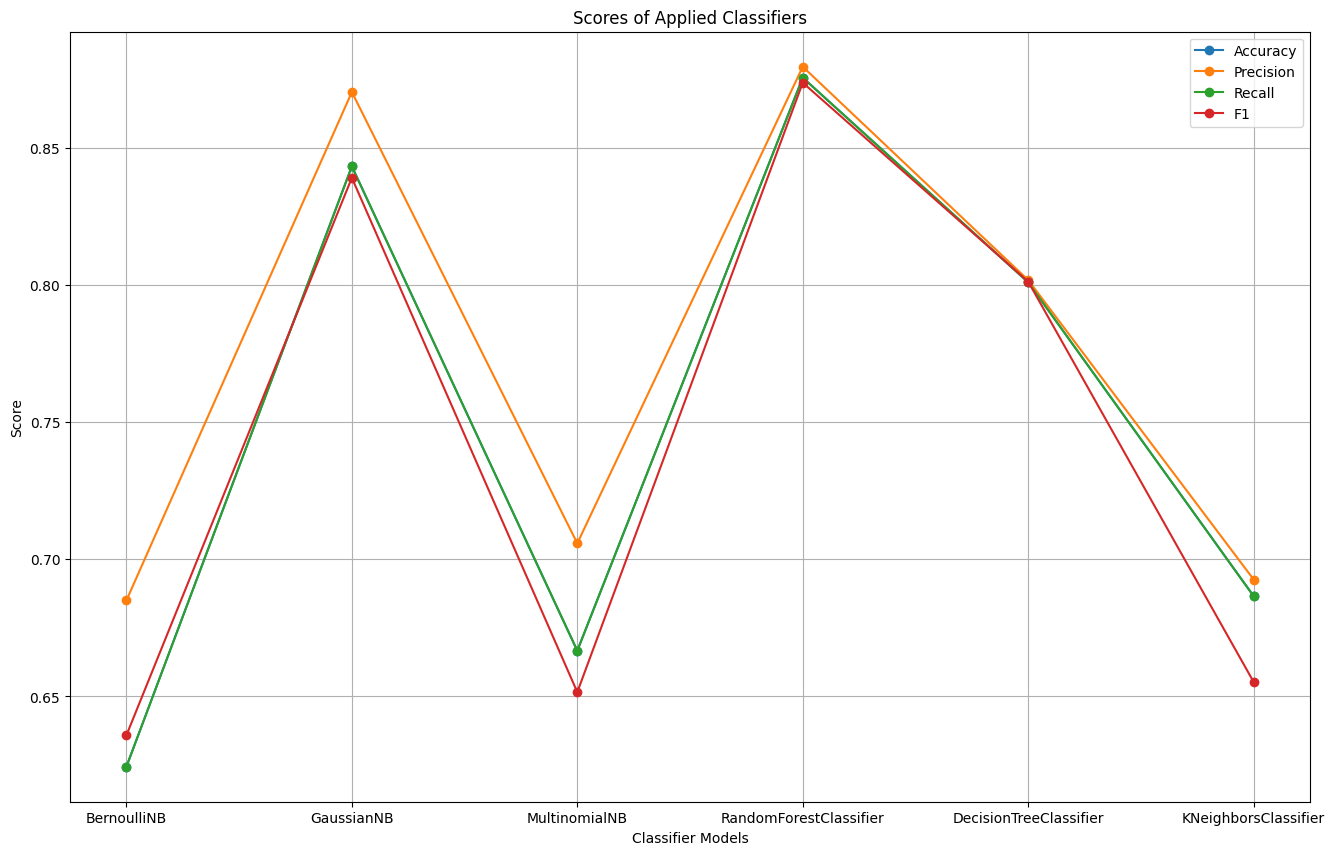

In [82]:
# Plotting Line Graph Showcasing all the Scores of applied Classifiers
plt.figure(figsize=(16,10))

x_labels = model_names # Use the model names from the previous execution

plt.plot(x_labels, results['Accuracy'], marker = 'o', label='Accuracy')
plt.plot(x_labels, results['Precision'], marker = 'o', label='Precision')
plt.plot(x_labels, results['Recall'], marker = 'o', label='Recall')
plt.plot(x_labels, results['F1'], marker = 'o', label='F1')

plt.title("Scores of Applied Classifiers")
plt.xlabel("Classifier Models")
plt.ylabel("Score")
plt.legend()
plt.grid(True)
plt.show()

# bar graph

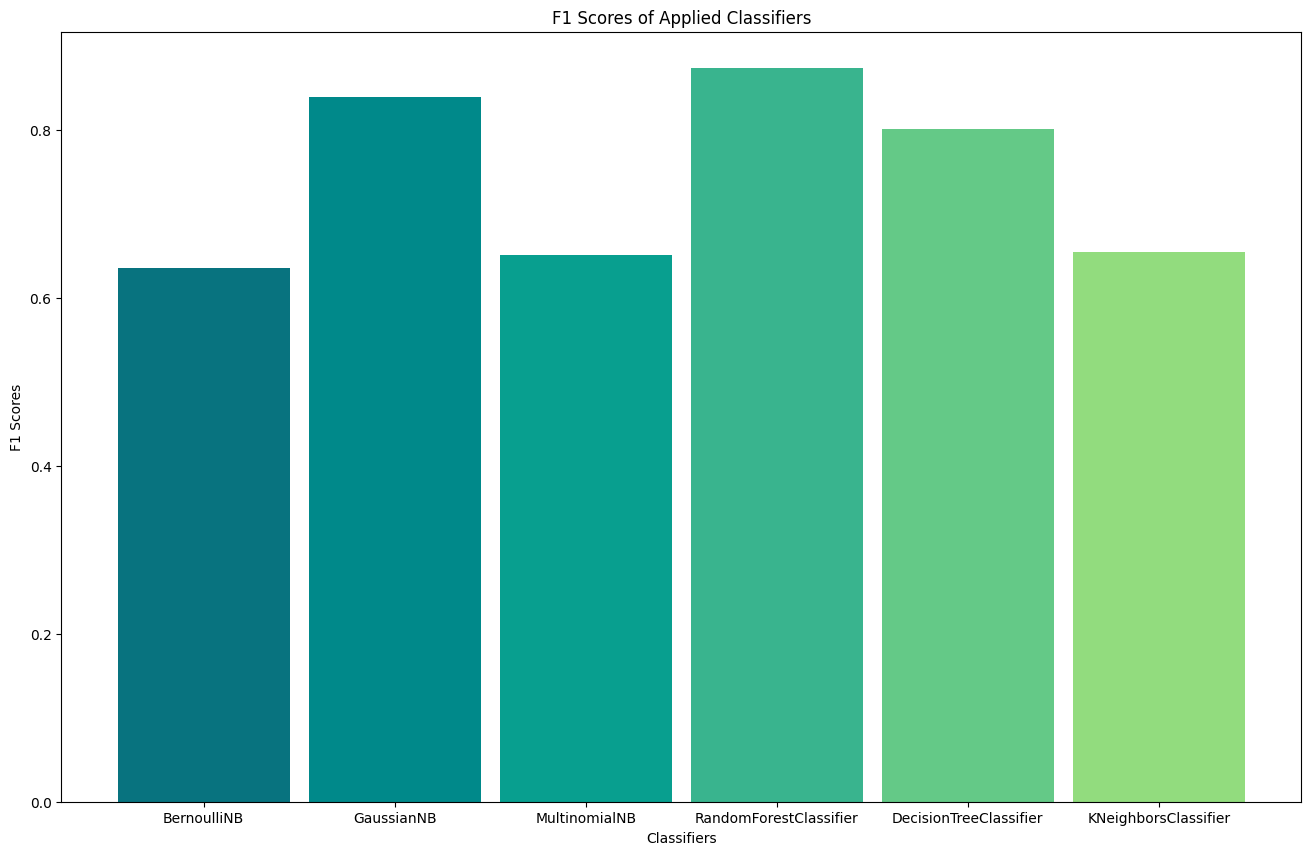

In [84]:
left = [1, 2, 3, 4, 5, 6]
plt.figure(figsize=(16,10))
# heights of bars
height = results['F1'] # Use F1 scores from the results dictionary
# labels for bars
tick_label = model_names # Use the model names from the previous execution
# plotting a bar chart
plt.bar(left, height, tick_label = tick_label, width = 0.9, color = ['#08737f', '#00898a', '#089f8f', '#39b48e', '#64c987',
'#92dc7e'])
# naming the x-axis
plt.xlabel('Classifiers')
# naming the y-axis
plt.ylabel('F1 Scores')
# plot title
plt.title('F1 Scores of Applied Classifiers')
# function to show the plot
plt.show()